# **Detector de Conflitos em Textos - PGC UFABC**

Espaço para desenvolvimento, teste e implementação do modelo de detecção de conflitos em textos, proposto no Projeto de Graduação em Computação da Universidade Federal do ABC



**Orientandos:**

*   Caio Cardoso dos Santos
*   Victor Ravazio de Lima

**Orientador:**

*   Prof. Dr. Carlos da Silva dos Santos




# **Conceitos e direções**

## **Conceiros essenciais - Super Resumo**



*   BERT - Modelo de Linguagem baseado em Transformers - Aprende relações semanticas profundas em textos

*   BERTimbau - BERT pré-treinado em portugês Br

*   Tokenizer - converte texto em numeros (IDS), onde cada inteiro é um indice no vocabulo.

  EX: "Eu adorei esse produto" => input_ids = [101, 1198, 17842, 1239, 15323, 102].
  
  Basicamento o Bert possui um dicionario estático e cada valor desse vetor de input corresponde a posição em que determinada palavra ou prefixo está localizada neste dicionario.


*   Fine-tuning - Ajustar o modelo para a tarefa especifica
*   Modelo: [neuralmind/bert-base-portuguese-cased](https://https://huggingface.co/neuralmind/bert-base-portuguese-cased)

**Fonte:** @inproceedings{souza2020bertimbau,
  author    = {F{\'a}bio Souza and
               Rodrigo Nogueira and
               Roberto Lotufo},
  title     = {{BERT}imbau: pretrained {BERT} models for {B}razilian {P}ortuguese},
  booktitle = {9th Brazilian Conference on Intelligent Systems, {BRACIS}, Rio Grande do Sul, Brazil, October 20-23 (to appear)},
  year      = {2020}
}

Fontes auxiliares e projetos:

Fonte 2: https://arthuremanuel-carosia.medium.com/usando-o-bert-para-an%C3%A1lise-de-sentimentos-363f76eee15e

Fonte 3: https://gist.github.com/Hugobsan/b507b76c7b5fc470d77b3a924211430d#file-pr-processamento-ipynb




##**Pipeline idealizado (provisório?)**


Dado o Dataset com Tweets:

*   Cada Dataset temático é divido em 3 subestruturas: Tweets genéricos, repys e quotes


  
*   Gera-se pares de tweets dentro de uma mesma subestrutura: Reply com seu respectivo replied tweet; Quote com seu respsctivo Quoted tweet; e original pareado com outro tweet origginal de forma aleatoria (amostragem aleatoria)

*   Para cada par de frases de cada grupo, constrói um dataset com essas informações: frase_1 - frase_2 - Classe - conflito (0/1)
*   Esta tabela seria o dataset de entrada para o bert - Este então aprende os padrões textuais que geralmente associam conflitos - “Que tipo de relação semântica entre frase_1 e frase_2 gera um situação de conflito 1?” -  Ex: bom x ruim; ótimo x péssimo

*   O modelo no fim é necessário pois ele aprende uma fronteira suave e não discreta.






# **Preparação do ambiente**


## **Validando GPU**

In [205]:
!nvidia-smi #verificando se o ambiente está configurado para GPU


Sat Jul 18 15:42:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             33W /   70W |    2319MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## **Instalando bibliotecas**

**Sobre as bibliotecas:**


*   Transformers (coleção de modelos pré-treinados em Transformers)
*   datasets (fornece alguns datasets otimizados prontos)
*   accelerate (gerencia multi gpu/otimiza treino em gpu)
*   evaluate (biblioteca de metricas padronizadas)

*   PyTorch (framework de deep learning)

* As 4 primeiras pertencem ao Hugging Face, espécie de "GitHub" de modelos IA







In [206]:
#Instalando:
!pip install -q transformers datasets torch accelerate evaluate

In [207]:
#!pip install torchcodec

In [208]:
!pip install --upgrade datasets transformers


In [209]:
#!pip install torchvision==0.21.0 #caso ocorra erro no treinamento, necessario instalar versão anaterior do torchvision

In [210]:
# modulo para importar dataset a partir de um link
!pip install gdown

# **Importações**

## **Importando Bibliotecas**

**Sobre as bibliotecas:**

*  Torch (Framework para aplicações de machine learn: abstrai tarefas, operacionaliza manipulação de tensores e etc)

*  BertTokenizer(Tokenizar textos)
*   BertModel (Bert puro)
*   BertForSequenceClassification (BERT + Camada de classificador)
*   Trainer (modulo para treino)

*   TrainigArguments (modulo para treino)

*   Gdown (baixar arquivos direto do drive)

* Dataset (otimiza e facilita a formatação do datataset para treino no Bert)

* sklearn (biblioteca que fornece ferramentas prontas para realizar tarefas de ML, como por exemplo "train_test_split" que divide automaticamente treino e teste, ou as metricas de avaliação que abstrai os calculos de precisão, recall e etc)






In [211]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gdown
from google.colab import files


from transformers import (
    BertTokenizer,
    BertModel,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed
)

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.special import softmax




## **Importando o Modelo**

In [212]:
# Escolher a versão a ser utilizada e comentar a outra!

#BERTimbau Base:
#Tokenizer
tokenizer = BertTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")

#Modelo: BERT + Camada de classificação
#num_labels corresponde ao numero de classes do modelo (Conflito/não conflito)
model = BertForSequenceClassification.from_pretrained("neuralmind/bert-base-portuguese-cased", num_labels = 2, problem_type="single_label_classification")

#setando a semente
set_seed(42)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

## **Importando o dataset**

Observações:


*   O dataset final é a junção dos datasets das etapas 1 e 2
*   A etapa 1 consistiu em uma anotação manual dos dados de maneira aleatória, ou seja, sem nenhum viés
*   Já a etapa 2 consistiu numa anotação manual "induzida pela probabilidade de conflito": Rodamos o classificador em um dataset anotado e o mesmo retornou probabilidade de conflitos para cada dado, nos quais foram posteriormente anotados manualmente em ordem decrescente de probabilidade de conflitos. Desta forma, existe um viés do prórprio modelo neste dataset da etapa 2

Desta forma, para evitar qualquer tipo de viés, o conjunto de teste final será formado somente por dados do dataset da etapa 1. Por outro lado, o conjunto de treino será formado pelo conjunto de treino obtido do split "train_test" do dataset da etaoa 1, concatenado com o dataset da etapa 2.

In [213]:
# baixando dataset para o collab
# file_id = "1kg61VoWDD_yGehSMlDbHhC1ltVWmeMF5" # dataset final (Etapa 1 + etapa 2)
file_id = "1LCBo7MOiePU_MyspswVt9R8a8vuR-y2W" # dataset final (Etapa 1 + etapa 2 + etapa 3)
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "dataset_conflitos.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1LCBo7MOiePU_MyspswVt9R8a8vuR-y2W
To: /content/dataset_conflitos.csv
100%|██████████| 1.13M/1.13M [00:00<00:00, 11.1MB/s]


'dataset_conflitos.csv'

In [214]:
#carregando o dataset
df = pd.read_csv ("dataset_conflitos.csv")
df['Conflict'] = df['Conflict'].astype(int) #convertendo valores para inteiros
#df = df[df['Conflict'] != -1] #eliminando indeterminados
df.shape

(3572, 5)

In [215]:
# Verificando distribuição das classes (DF_final - Etapas 1 e 2)
conflitos = df[df["Conflict"] == 1].shape[0]
nao_conflitos = df[df["Conflict"] == 0].shape[0]
print("Quantidade de anotações por classes:")
print("0 - Não Conflitos: ", nao_conflitos)
print("1 - Conflitos: ", conflitos)
print(f"Desbalanceamento: {(max(nao_conflitos, conflitos) / min(nao_conflitos, conflitos)):.3f} : 1")

Quantidade de anotações por classes:
0 - Não Conflitos:  2263
1 - Conflitos:  1237
Desbalanceamento: 1.829 : 1


In [216]:
# Recuperando/separando df original e df induzido - Ideia: Obter o conjunto de teste a partir apenas do df original (Evitando viés)
#obs - df_etapa 1 - [0:1524]; df_etapa 2 - [1510-2028]; df_etapa 3 = [2029:final]

original_shape = 1524
df_original = df.loc[:original_shape,:]
df_induzido = df.loc[original_shape+1:,:] #obs - df_df_etapa 1 - [1510-2028]; df_etapa 3 = [2029:final]
(df_original.shape, df_induzido.shape)



((1525, 5), (2047, 5))

In [217]:
# eliminando indeterminados
df_original = df_original[df_original['Conflict'] != -1]
df_induzido = df_induzido[df_induzido['Conflict'] != -1]
(df_original.shape, df_induzido.shape)

((1500, 5), (2000, 5))

In [218]:
df = df_original
df

,tweet_1,tweet_2,Tema,Class,Conflict
0,#AbortoNao crianças em internatos não é conseq...,0 ARGUMENTOS pra esse povo q apoia aborto #Abo...,Aborto,0,0
1,#AbortoNao Não vamos deixar o STF legislar ma...,#AbortoSim o feto não é considerado humano an...,Aborto,0,1
2,#AbortoNao é um crime o pautar um assunto tão...,Quem comete aborto mata um ser inocente que nã...,Aborto,0,0
3,Tentar reduzir o aborto a uma questão de saúde...,Todos os homens são contra o aborto até o dia ...,Aborto,0,1
4,"#AbortoNao ou #AbortoSIM Não tenho útero, ent...",O Brasil é cristão e conservador! #AbortoNao,Aborto,0,0
...,...,...,...,...,...
1520,Bolsonaro tem muita dificuldade de achar subst...,Principalmente porque o principl requisito que...,Mandetta,2,0
1521,Mandetta já sabia da Pandemia no Carnaval. Ao ...,#ForaMandettaUrgente ATITUDE presidente,Mandetta,2,0
1522,Planalto investiga assessores de Mandetta e pr...,"Demorou, caça as bruxas...beginning...o pior m...",Mandetta,2,0
1523,Mandetta e sua política de isolamento estão lo...,Cansei de falar isso!,Mandetta,2,0


In [219]:
df_induzido

,tweet_1,tweet_2,Tema,Class,Conflict
1525,"Estamos em 2020 século 21, as mulheres ainda n...","Qd vc abre a hastag #AbortoNao, a unica coisa ...",Aborto,0,0
1526,#AbortoNao Jamais ! Sim a vida .,"Vc é contra o aborto por se declarar pró vida,...",Aborto,0,1
1527,#AbortoNunca ENTENDAM quando a pessoa é #Abort...,vcs falam #AbortoNao como se existisse um méto...,Aborto,0,0
1528,Aborto não é método contraceptivo!antes de esc...,Vai caça o que fazer e deixa as mulheres escol...,Aborto,1,1
1529,Pelo simples fato de que matar uma vida humana...,@ Vida é a partir do embrião.E embrião é vida....,Aborto,1,1
...,...,...,...,...,...
3567,Desejo ao Dr. Nelson Teich novo Ministro da Sa...,eu tava no cagaço do dia que eu ia ler essa no...,Mandetta,0,0
3568,Moro: técnico; Guedes: técnico; Pontes: técnic...,Mandetta não é técnico por qual critério? No m...,Mandetta,1,1
3569,Mandetta fica como prova didática de que nem p...,Definição mais cirúrgica que li sobre o papel ...,Mandetta,1,0
3570,No meio de uma pandemia mundial o bonitão demi...,Bolsonaro é um rato oportunista. Demitiu Mande...,Mandetta,0,0


In [220]:
# Verificando distribuição das classes (DF_Original)
conflitos = df[df["Conflict"] == 1].shape[0]
nao_conflitos = df[df["Conflict"] == 0].shape[0]
print("Quantidade de anotações por classes:")
print("0 - Não Conflitos: ", nao_conflitos)
print("1 - Conflitos: ", conflitos)
print(f"Desbalanceamento: {(max(nao_conflitos, conflitos) / min(nao_conflitos, conflitos)):.3f} : 1")

Quantidade de anotações por classes:
0 - Não Conflitos:  1164
1 - Conflitos:  336
Desbalanceamento: 3.464 : 1


In [221]:
# Embaralhando o dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df

,tweet_1,tweet_2,Tema,Class,Conflict
0,Mandetta cavou a própria cova pra ser demitido...,"Assista a ""Live: Bolsonaro demite Mandetta. E ...",Mandetta,0,0
1,"Para surpresa de ninguém, o boato que deputado...",A fritura do Mandetta começou do jeito mais ef...,Mandetta,2,0
2,Obesidade mata muito muito muito mais que abor...,"Questão de saúde, diz o panguado q num sabe q ...",Aborto,1,0
3,"Aborto somente dos deputados, senadores e mini...",#AbortoNao Por mais que eu PESSOALMENTE seja c...,Aborto,0,0
4,"se vcs barrarem o protocolo da cloroquina, pod...",Por que o presidente insiste na cloroquina? Po...,Cloroquina,0,1
...,...,...,...,...,...
1495,Bolsonaro demite Mandetta; Nelson Teich assume...,76% dos brasileiros rejeitam a demissão do min...,Mandetta,0,0
1496,A maioria esmagadora dos brasileiros é contrár...,Sabe o pq? Pq nos últimos anos não tiveram min...,Mandetta,1,0
1497,#VozParaBernardoKuster Coincidência...sai pesq...,"Bom Dia, Rio Grande do Sul Voltou o frio #Fiq...",Contas suspensas,0,0
1498,"De acordo com a nova Pesquisa do Atlas, Mandet...",Galera vote e compartilhe! NÃO CURTA!,Mandetta,2,0


# **Modelo - Conflict Detector**

## **Separando treino e teste**

In [222]:
#Separando dados em treino e teste
# train_test_split é um método da biblioteca sklearn que abstrai a divisão de treino e test
# O parametro stratify mantém a proporção das classes - Originalmente 80% não conflito e 20% não conflito, assim também será em train e test.
train_df, test_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df["Conflict"])

print("Treino:", len(train_df))
print("Teste:", len(test_df))


Treino: 1050
Teste: 450


In [223]:
#Verificando distribuições das classes pré-balanceamento
conflitos = train_df[train_df["Conflict"] == 1].shape[0]
nao_conflitos = train_df[train_df["Conflict"] == 0].shape[0]
print("Quantidade de anotações por classes:")
print("0 - Não Conflitos: ", nao_conflitos)
print("1 - Conflitos: ", conflitos)
print(f"Desbalanceamento: {(max(nao_conflitos, conflitos) / min(nao_conflitos, conflitos)):.3f} : 1")

Quantidade de anotações por classes:
0 - Não Conflitos:  815
1 - Conflitos:  235
Desbalanceamento: 3.468 : 1


## **Balanceamento - Undersampling**

In [224]:
# #----------------Equilibrando dados---------------------------
df_conflitos = train_df[train_df["Conflict"] == 1]
df_nao_conflitos = train_df[train_df["Conflict"] == 0]
df_nao_conflitos = df_nao_conflitos.sample(n=df_conflitos.shape[0]*3, random_state=42)

train_df = pd.concat([df_conflitos, df_nao_conflitos])

In [225]:
#Verificando novas distribuições das classes
conflitos = train_df[train_df["Conflict"] == 1].shape[0]
nao_conflitos = train_df[train_df["Conflict"] == 0].shape[0]
print("Quantidade de anotações por classes:")
print("0 - Não Conflitos: ", nao_conflitos)
print("1 - Conflitos: ", conflitos)
print(f"Desbalanceamento: {(max(nao_conflitos, conflitos) / min(nao_conflitos, conflitos)):.3f} : 1")

Quantidade de anotações por classes:
0 - Não Conflitos:  705
1 - Conflitos:  235
Desbalanceamento: 3.000 : 1


In [226]:
# Juntando os dados do dataset induzido no conjunto de treino:
train_df = pd.concat([train_df, df_induzido], ignore_index=True, axis = 0)
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_df, eval_df = train_test_split(train_df, test_size=0.20, random_state=42, stratify=train_df["Conflict"])
train_df

,tweet_1,tweet_2,Tema,Class,Conflict
2190,Que complicada esta decisão do Alexandre de Mo...,"‘Afronta à liberdade de expressão’, diz Lucian...",Contas suspensas,0,0
717,Eu pensei que estavam falando dos 3 abortinhos...,Mesmo que seja contrário as nossas crenças ( c...,Aborto,0,0
1429,"O apoio à censura, que interessante. Isso é co...",Repitam quantas vezes isso for suficientes pra...,Contas suspensas,1,0
1067,"A pasta da Saúde, por si só, é 1 enorme desafi...",Mandetta saiu o quê??? Hahaha Piada né Senador...,Mandetta,1,1
2415,"apenas 9 milhões de pessoas são ""aprovadas"" pr...",Saiu o Mandetta ultra-liberal e vai entrar o m...,Mandetta,0,0
...,...,...,...,...,...
661,Censura nunca mais!,"Oxe, não são vcs que pedem intervenção militar...",Contas suspensas,1,1
2006,"Quem comemora a censura hoje, será alvo da cen...",Se precisa calar é pq a esquerda precisa apela...,Contas suspensas,1,0
2202,"Caro presidente , não seria interessante já m...",Cloroquina é o meu ovo,Cloroquina,0,0
2805,Assim como tem cientista tendo bom resultados ...,O pior é ver pessoas que defendem a liberdade ...,Cloroquina,1,0


In [227]:
#convertendo para o formato "datasets" do Hugging face - Abstrai alguns procedimentos, como formatar para tensores e etc
train_dataset = Dataset.from_pandas(train_df, preserve_index=False) #index = false - não inclui os indices do df original
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)
eval_dataset = Dataset.from_pandas(eval_df, preserve_index=False)

print("Treino:", len(train_dataset))
print("Teste:", len(test_dataset))
print("Validação:", len(eval_dataset))


Treino: 2352
Teste: 450
Validação: 588


In [228]:
train_dataset

Dataset({
    features: ['tweet_1', 'tweet_2', 'Tema', 'Class', 'Conflict'],
    num_rows: 2352
})

## **Tokenização**

1 - Tokenização consiste em transformar o texto bruto em uma representação numérica estruturada que o modelo BERT consiga processar. Para isso, o texto é dividido em subpalavras (subword tokenization), e cada token é convertido em um identificador numérico correspondente ao índice no vocabulário aprendido pelo modelo.

O processo de tokenização gera três principais componentes:

- input_ids: sequência de identificadores numéricos dos tokens.
- token_type_ids: indica a qual sentença cada token pertence (no caso de pares de sentenças).
- attention_mask: indica quais posições são tokens reais (1) e quais são padding (0).

Na abordagem adotada neste trabalho, a tokenização é feita em pares de tweets, explorando a arquitetura do BERT, que permite modelar relações entre duas sentenças simultaneamente. Dessa forma, o modelo aprende interações semânticas entre os dois textos, em vez de processá-los isoladamente.

A entrada do BERT segue o formato:

[CLS] texto_1 [SEP] texto_2 [SEP]

Para construir essa entrada, utiliza-se o tokenizer do BERT, passando ambos os textos como parâmetros, além de argumentos de controle como padding (para padronizar o tamanho das sequências) e truncation (para limitar o tamanho máximo).

Esses vetores tokenizados são então utilizados como entrada do modelo, que gera embeddings contextualizados para cada token.

Observação: o padding é necessário para garantir que todas as sequências de um batch tenham o mesmo tamanho, já que o processamento é realizado em lotes (batches). Isso é essencial para a eficiência computacional e compatibilidade com o formato esperado pelo modelo.

2 - Este processo é realizado através da função tokenize_function, que aplica o tokenizer do BERT (carregado na etapa de importação) em cada elemento do dataset. No caso deste trabalho, a tokenização é aplicada a pares de tweets.


3 - O metodo "map" a seguir, que pertence a biblioteca "datasets" do Hugging Face, aplica tokenize_function em cada entrada do df e faz o merge do resultado com as colunas originais
EX:
    # originaal:'tweet_1', 'tweet_2', 'Class', 'Conflict;
    # Tokenize: 'input_ids', 'token_type_ids', 'attention_mask'
    # Map: 'tweet_1', 'tweet_2', 'Class', 'Conflict', 'input_ids', 'token_type_ids', 'attention_mask'
     
Naturalmente "train_dataset" e "test_dataset" é um objeto "Dataset" (da biblioteca do hugging face)

In [229]:
#Função de tokenização
def tokenize_function(pair):

    return tokenizer(
        pair["tweet_1"],
        pair["tweet_2"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [230]:
#Aplicando a Tokenização
train_dataset = train_dataset.map(tokenize_function)
test_dataset = test_dataset.map(tokenize_function)
eval_dataset = eval_dataset.map(tokenize_function)

Map:   0%|          | 0/2352 [00:00<?, ? examples/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Map:   0%|          | 0/588 [00:00<?, ? examples/s]

In [231]:
#Formato pós tokenização
train_dataset

Dataset({
    features: ['tweet_1', 'tweet_2', 'Tema', 'Class', 'Conflict', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2352
})

In [232]:
#Exemplo
print(train_dataset[0])

{'tweet_1': 'Que complicada esta decisão do Alexandre de Moraes, né? "(...) evitando-se que continuem a ser utilizados como instrumento do cometimento de **P-O-S-S-Í-V-E-I-S** condutas criminosas apuradas nestes autos (...)"', 'tweet_2': '‘Afronta à liberdade de expressão’, diz Luciano Hang  via', 'Tema': 'Contas suspensas', 'Class': 0, 'Conflict': 0, 'input_ids': [101, 5724, 12543, 251, 418, 3087, 171, 5049, 125, 13770, 117, 149, 22300, 136, 107, 113, 119, 119, 119, 114, 16153, 118, 176, 179, 1236, 210, 123, 333, 5213, 271, 7325, 171, 662, 12411, 125, 115, 115, 212, 118, 231, 118, 200, 118, 200, 118, 2883, 118, 354, 118, 192, 118, 290, 118, 200, 115, 115, 13756, 22281, 5420, 3832, 15076, 591, 16613, 1846, 22281, 113, 119, 119, 119, 114, 107, 102, 8586, 5208, 1885, 154, 353, 4676, 125, 4587, 22361, 117, 1331, 14383, 5320, 22293, 1413, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0,

In [233]:
# Renomeando o atributo alvo - O modulo trainer espera o atributo alvo numa coluna "label"
train_dataset = train_dataset.rename_column("Conflict", "labels")
test_dataset = test_dataset.rename_column("Conflict", "labels")
eval_dataset = eval_dataset.rename_column("Conflict", "labels")
train_dataset

Dataset({
    features: ['tweet_1', 'tweet_2', 'Tema', 'Class', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2352
})

## **Formatando Tensores**

O Bert trabalha com tensores PyTorch, sendo necessária a conversão dos dados para este formato antes do treinamento.

Após a tokenização, os dados ainda estão em estruturas Python comuns (listas e inteiros). Para resolver isso, a biblioteca Datasets é bastante conveniente, pois o método set_format configura o dataset para que, no momento do acesso aos elementos (de forma lazy), as colunas especificadas sejam automaticamente convertidas para torch.Tensor.

O uso da biblioteca Datasets abstrai a necessidade de implementar manualmente uma classe "Dataset" do PyTorch (com métodos como __getitem__ e __len__), simplificando significativamente o pipeline de pré-processamento.

Pós-tokenização:
dataset[0] retorna:

"input_ids": [101, 2023, 2003],
"attention_mask": [1, 1, 1],
"labels": 1

Pós-formatação (set_format):
dataset[0] retorna:

"input_ids": tensor([...]),
"attention_mask": tensor([...]),
"labels": tensor(...)

     

In [234]:
# Formatando os Tensores:

train_dataset.set_format(
    type="torch",
    columns=["input_ids", "token_type_ids", "attention_mask", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "token_type_ids", "attention_mask", "labels"]
)

eval_dataset.set_format(
    type="torch",
    columns=["input_ids", "token_type_ids", "attention_mask", "labels"]
)

## **Métricas de avaliação**

Durante o treinamento, o Trainer (que será descrito na seção a seguir) avalia o modelo ao final de cada época utilizando um "eval_dataset" (metrica do trainer que corresponde ao conjunto de avaliação). Basicamente o modelo, ao fim de cada epoca, tenta realizar predições nos dados do eval_dataset (aqui, provisoriamente o proprio conjunto de teste esta sendo usado como avaliação). As saídas produzidas pelo modelo (logits) neste conjunto de avaliação são então convertidas em classes previstas e comparadas com os labels reais do dataset.

Em segguida, calcula-se as métricas de avaliação como accuracy, precision, recall e F1-score para medir a qualidade o modelo após cada época.

O Trainer então salva checkpoints do modelo durante o treinamento e utiliza o F1-score para identificar qual versão obteve o melhor desempenho.

A função a seguir, que realiza este processo de avaliação, será chamada automaticamente no final de cada época pelo Trainer (biblioteca pré carregada). O treiner, é configurado para realizar este processamento através de parametros durante sua chamada e pode ou não utilizar esta mecanica descrita, atraves da sobrecarga (passar parametros basicos só para treina, ou passar mais parametros, incluindo a função a seguir, indicando que quer realizar esta mecanica)  

Ao final do treinamento, o Trainer recarrega automaticamente o checkpoint com melhor F1-score.


In [235]:
#computando metricas de avaliação
# eval_pred é o que o modelo previu no conjunto de avaliação e seus rotulos reais
# Essa função é chamada pelo "Trainer"

def compute_metrics(eval_pred):

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {

        # Accuracy
        "accuracy": accuracy_score(labels, predictions),

        # Classe positiva (Conflito)
        "precision_conflict": precision_score(labels, predictions, average="binary", zero_division=0),
        "recall_conflict": recall_score(labels, predictions, average="binary", zero_division=0),
        "f1_conflict": f1_score(labels, predictions, average="binary", zero_division=0),

        # Macro
        "precision_macro": precision_score(labels, predictions, average="macro", zero_division=0),
        "recall_macro": recall_score(labels, predictions, average="macro", zero_division=0),
        "f1_macro": f1_score(labels, predictions, average="macro", zero_division=0),

        # Weighted
        "precision_weighted": precision_score(labels, predictions, average="weighted", zero_division=0),
        "recall_weighted": recall_score(labels, predictions, average="weighted", zero_division=0),
        "f1_weighted": f1_score(labels, predictions, average="weighted", zero_division=0),
    }

## **Treinamento**

A biblioteca Hugging Face fornece duas classes principais para o treinamento de modelos Transformer:  TrainingArguments e Trainer. Essas classes abstraem grande parte do processo de treinamento, evitando a necessidade de criar manualmente todo o loop de treino.

O TrainingArguments funciona como uma configuração geral que nos permite "personalizar" como o treinamento será executado. Nele podemos definir parâmetros como:  número de épocas, batch size, learning rate estratégia de avaliação, estratégia de salvamento, diretórios de logs e checkpoints

Já o Trainer é a classe responsável por executar o treinamento propriamente dito, utilizando o modelo, os datasets, os parâmetros definidos em TrainingArguments e a função de métricas. Durante o treinamento, a cada época, o Trainer percorre o dataset de treino em batches e, a cada batch, o modelo realiza o forward pass (processo em que os dados de entrada são propagados pela rede neural para gerar uma predição, basicamente calcular a saída para uma entrada específica). Em seguida, calcula-se a loss e realiza-se a agragação dos valores calculados da loss de cada item da batch (formando assim uma unica loss para a batch), executa-se a backpropagation e os pesos da rede são atualizados. Essas atualizações ocorrem batch a batch.

Após todos os batches de uma época serem processados, o Trainer executa automaticamente uma etapa de avaliação utilizando o eval_dataset (conjunto de validação fornecido na instanciação do Trainer). Nessa etapa, o modelo realiza o forward pass sobre os dados de validação e produz logits, que são os valores brutos de saída da rede neural antes da aplicação de uma função de ativação. Em seguida, esses logits são convertidos em classes por meio da seleção do maior valor (argmax). O Trainer então chama automaticamente a função compute_metrics(), responsável por calcular as métricas de avaliação a partir dessas predições.

In [236]:
#Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01, #controla tamanho dos pesos para evitar overfitting
    logging_dir="./logs",
    seed=42,
    data_seed=42,
    load_best_model_at_end=True,
    metric_for_best_model="f1_conflict"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [237]:
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics
)

In [238]:
# Treinando:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Conflict,Recall Conflict,F1 Conflict,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.625691,0.560435,0.704082,0.705426,0.400881,0.511236,0.704565,0.647809,0.649520,0.704369,0.704082,0.681034
2,0.458067,0.509118,0.751701,0.707692,0.607930,0.654028,0.740615,0.725017,0.730197,0.748117,0.751701,0.747555
3,0.330369,0.552500,0.739796,0.659483,0.674009,0.666667,0.725809,0.727586,0.726639,0.740924,0.739796,0.740306
4,0.247485,0.596938,0.741497,0.666667,0.660793,0.663717,0.727273,0.726518,0.726886,0.741084,0.741497,0.741282


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1176, training_loss=0.41540325580000065, metrics={'train_runtime': 350.8872, 'train_samples_per_second': 26.812, 'train_steps_per_second': 3.352, 'total_flos': 618837202206720.0, 'train_loss': 0.41540325580000065, 'epoch': 4.0})

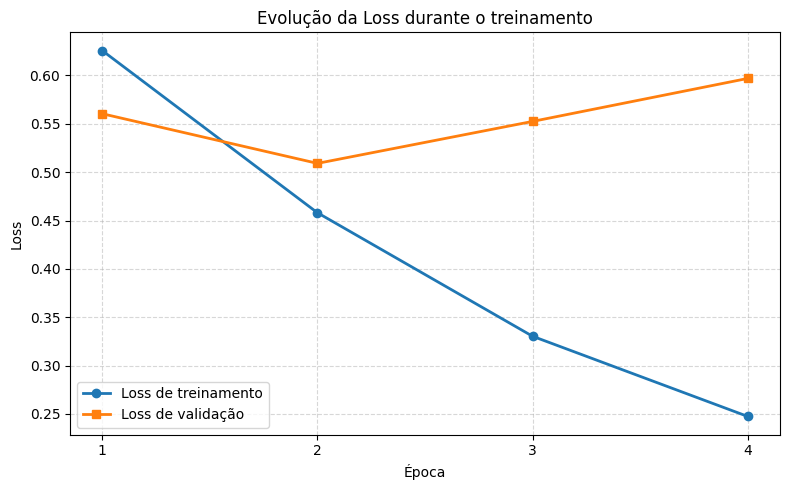

In [239]:
# Loss x Epoch
# Histórico do treinamento
logs = pd.DataFrame(trainer.state.log_history)

# Logs de treinamento
train_logs = logs[logs["loss"].notna()]

# Logs de validação
eval_logs = logs[logs["eval_loss"].notna()]

plt.figure(figsize=(8,5))

# Loss de treinamento
plt.plot(
    train_logs["epoch"],
    train_logs["loss"],
    marker="o",
    linewidth=2,
    label="Loss de treinamento"
)

# Loss de validação
plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_loss"],
    marker="s",
    linewidth=2,
    label="Loss de validação"
)

plt.title("Evolução da Loss durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.xticks(sorted(eval_logs["epoch"].unique()))  # mostra apenas épocas inteiras
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

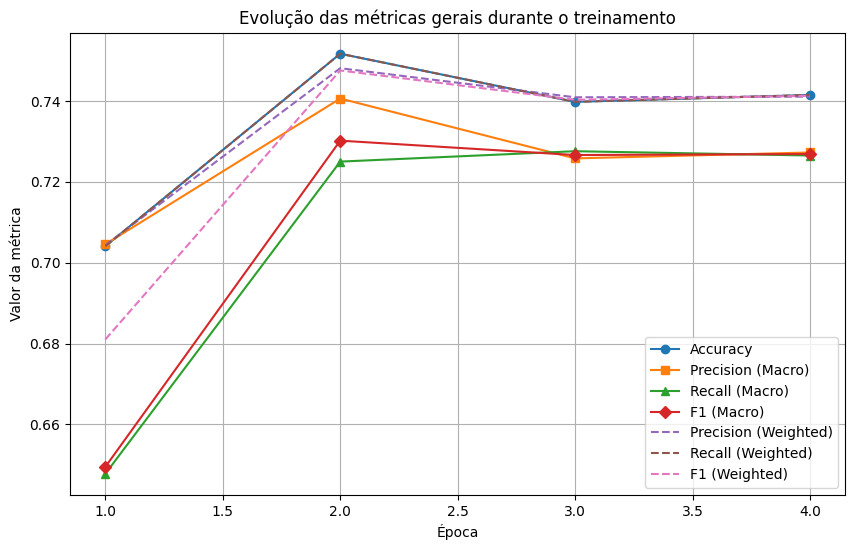

In [240]:
# Evolução das metricas gerais ao longo do treinamento

plt.figure(figsize=(10,6))

plt.plot(eval_logs["epoch"], eval_logs["eval_accuracy"],
         marker="o", label="Accuracy")

plt.plot(eval_logs["epoch"], eval_logs["eval_precision_macro"],
         marker="s", label="Precision (Macro)")

plt.plot(eval_logs["epoch"], eval_logs["eval_recall_macro"],
         marker="^", label="Recall (Macro)")

plt.plot(eval_logs["epoch"], eval_logs["eval_f1_macro"],
         marker="D", label="F1 (Macro)")

plt.plot(eval_logs["epoch"], eval_logs["eval_precision_weighted"],
         linestyle="--", label="Precision (Weighted)")

plt.plot(eval_logs["epoch"], eval_logs["eval_recall_weighted"],
         linestyle="--", label="Recall (Weighted)")

plt.plot(eval_logs["epoch"], eval_logs["eval_f1_weighted"],
         linestyle="--", label="F1 (Weighted)")

plt.xlabel("Época")
plt.ylabel("Valor da métrica")
plt.title("Evolução das métricas gerais durante o treinamento")

plt.grid(True)
plt.legend()
plt.show()

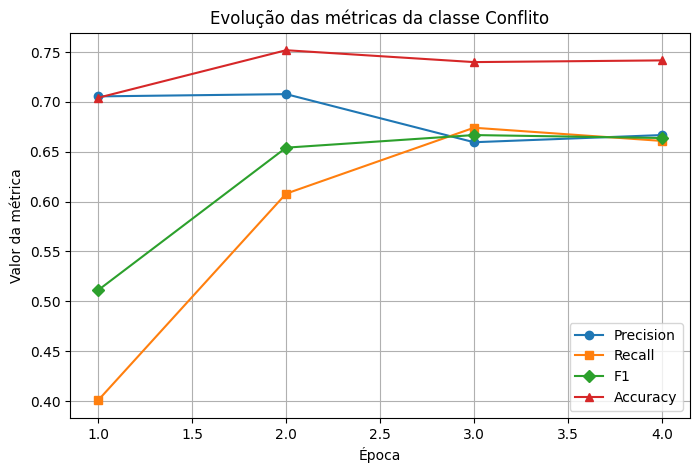

In [241]:
# Evolução da classe conflito ao longo do treinamento
plt.figure(figsize=(8,5))

plt.plot(eval_logs["epoch"], eval_logs["eval_precision_conflict"],
         marker="o", label="Precision")

plt.plot(eval_logs["epoch"], eval_logs["eval_recall_conflict"],
         marker="s", label="Recall")

plt.plot(eval_logs["epoch"], eval_logs["eval_f1_conflict"],
         marker="D", label="F1")

plt.plot(eval_logs["epoch"], eval_logs["eval_accuracy"],
         marker="^", label="Accuracy")

plt.xlabel("Época")
plt.ylabel("Valor da métrica")
plt.title("Evolução das métricas da classe Conflito")

plt.grid(True)
plt.legend()
plt.show()

In [242]:
# avaliando
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision Conflict,Recall Conflict,F1 Conflict,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
0.247485,0.552500,4,0.739796,0.659483,0.674009,0.666667,0.725809,0.727586,0.726639,0.740924,0.739796,0.740306


{'eval_loss': 0.5525002479553223, 'eval_accuracy': 0.7397959183673469, 'eval_precision_conflict': 0.6594827586206896, 'eval_recall_conflict': 0.6740088105726872, 'eval_f1_conflict': 0.6666666666666666, 'eval_precision_macro': 0.725808795040682, 'eval_recall_macro': 0.7275861227378672, 'eval_f1_macro': 0.7266387726638772, 'eval_precision_weighted': 0.7409239121840134, 'eval_recall_weighted': 0.7397959183673469, 'eval_f1_weighted': 0.7403058852550783}


In [243]:
# Avaliando o modelo no conjunto de Teste - Limiar ajustável
threshold = 0.50
# Predições no teste
test_predictions = trainer.predict(test_dataset) #retorna logits

# Probabilidade da classe positiva (conflito)
test_probs = softmax(
    test_predictions.predictions,
    axis=1
)[:, 1] #transforma as previsoes em probabilidades -
 #neste caso ele passa considerar somente a probabilidade da classe 1 como conflito ou não conflito -
 # ex: tenho [X,Y] -> Aplica softmax em "Y", temos por exemplo, 0,25 - 25% - se threashold for 0,25,
 #então prev desta entrada = 1/conflito

# Aplicando melhor threshold
y_pred = (test_probs >= threshold).astype(int)

y_true = test_predictions.label_ids

print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       349
           1       0.55      0.59      0.57       101

    accuracy                           0.80       450
   macro avg       0.71      0.73      0.72       450
weighted avg       0.80      0.80      0.80       450



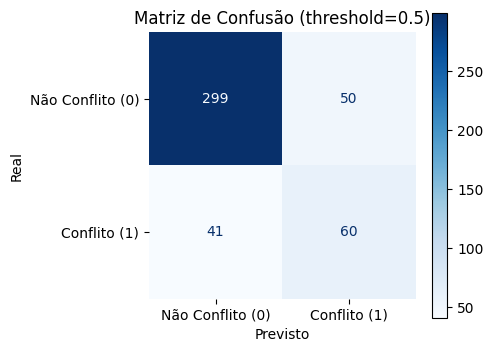

In [244]:
#MATRIZ DE CONFUSÃO
# nomes das classes
labels = ["Não Conflito (0)", "Conflito (1)"]

mat = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5,4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=mat,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

ax.set_xlabel("Previsto")
ax.set_ylabel("Real")

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(False)

plt.title(
    f"Matriz de Confusão (threshold={threshold})"
)

plt.tight_layout()
plt.show()

# **Analise exploratória - Falsos Negativos**

In [ ]:
# Recuperando as classificações para analises
predictions = trainer.predict(test_dataset) # realiza predição

logits = predictions.predictions #guarda os logits
y_true = predictions.label_ids
y_pred = np.argmax(logits, axis=1)

# Softmax -> probabilidades
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()

#criando o dataset
analise = test_df.reset_index(drop=True).copy()

analise["classe_real"] = y_true
analise["classe_predita"] = y_pred

analise["prob_nao_conflito"] = probs[:,0]
analise["prob_conflito"] = probs[:,1]

In [ ]:
#falsos negativos
falsos_negativos = analise[
    (analise["classe_real"] == 1) &
    (analise["classe_predita"] == 0)
]
falsos_negativos

,tweet_1,tweet_2,Tema,Class,Conflict,classe_real,classe_predita,prob_nao_conflito,prob_conflito
1,vcs do #abortonao se preocupem com as crianças...,"O discurso de genocidas é assim mesmo: ""Vamos ...",Aborto,1,1,1,0,0.868545,0.131455
14,"Veja: ""Sílvio Santos também indica nome a Bols...",E porque mantém a imbecil da Raquel cheira p*...,Mandetta,2,1,1,0,0.944361,0.055639
24,"Homens palpitando sobre aborto, “pipipopo pres...",O mais irônico da AbortoSim vs #AbortoNao É ...,Aborto,0,1,1,0,0.879422,0.120578
41,O divulga orientações para tratamento da Covi...,enfia a Cloroquina no seu cu,Cloroquina,1,1,1,0,0.609816,0.390184
48,Grande dia As contas dos pilantras dos passa...,"Os defensores da dEmOCrAcIa amam uma censura, ...",Contas suspensas,2,1,1,0,0.941788,0.058212
53,Não adianta falar #AbortoNão.O aborto é uma re...,“O dever do Estado diante disso tudo é justame...,Aborto,2,1,1,0,0.935065,0.064935
69,Não dá para acreditar. O que é isso?,"Oi , interessante você ter feito uma postagem...",Cloroquina,2,1,1,0,0.669871,0.330129
81,O divulga orientações para tratamento da Covi...,Protocolo não tem assinatura de NENHUM MÉDICO....,Cloroquina,1,1,1,0,0.655404,0.344596
92,Acho bom o Mandetta sair Vai morrer mais gent...,Mandetta elogiou o Moro Elogiou o Guedes e ain...,Mandetta,1,1,1,0,0.722383,0.277617
127,A maioria esmagadora dos brasileiros é contrár...,A mesma maioria esmagadora que iria eleger Had...,Mandetta,1,1,1,0,0.502431,0.497569


In [ ]:
#imprimindo Falsos Negativos
for _, row in falsos_negativos.iterrows():
    print(f"Tema: {row['Tema']}")
    print(f"Classe: {row['Class']}")
    print("Tweet 1:")
    print(row["tweet_1"])
    print("Tweet 2:")
    print(row["tweet_2"])
    print(f"P(Não conflito): {row['prob_nao_conflito']:.4f}")
    print(f"P(Conflito):     {row['prob_conflito']:.4f}")
    print()

Tema: Aborto
Classe: 1
Tweet 1:
vcs do #abortonao se preocupem com as crianças abandonadas nas ruas e em orfanatos e deixem as mulheres decidirem sobre seu próprio corpo #AbortoSim
Tweet 2:
O discurso de genocidas é assim mesmo: "Vamos matar antes que eles morram de outra forma no futuro." #AbortoNAO
P(Não conflito): 0.8685
P(Conflito):     0.1315

Tema: Mandetta
Classe: 2
Tweet 1:
Veja: "Sílvio Santos também indica nome a Bolsonaro para lugar de Mandetta. Apresentador pediu ao presidente para ouvir o diretor do Conselho do Hospital Albert Einstein, Claudio Lottenberg, antes de definir chefe da Saúde." SILVIO QUER AJUDAR E SE DIFERE DA MAIORIA DA IMPRENSA.
Tweet 2:
E porque mantém a  imbecil da Raquel cheira p* como apresentadora do jornal  sbt!
P(Não conflito): 0.9444
P(Conflito):     0.0556

Tema: Aborto
Classe: 0
Tweet 1:
Homens palpitando sobre aborto, “pipipopo preservativo tá aí, vários modos de prevenção teve pq quis” mas na hr H fica fazendo birra pra n usar pq “aperta” #Aborto

In [ ]:
cont_aborto = 0
cont_mandetta = 0
cont_cloroquina = 0
cont_contas = 0

sum_aborto = 0
sum_mandetta = 0
sum_cloroquina = 0
sum_contas = 0

In [ ]:
#imprimindo Falsos Negativos por Categoria
for _, row in falsos_negativos.iterrows():
    if(row['Tema'] == 'Aborto'):
      print(f"Tema: {row['Tema']}")
      print(f"Classe: {row['Class']}")
      print("Tweet 1:")
      print(row["tweet_1"])
      print("Tweet 2:")
      print(row["tweet_2"])
      print(f"P(Não conflito): {row['prob_nao_conflito']:.4f}")
      print(f"P(Conflito):     {row['prob_conflito']:.4f}")
      print()

      cont_aborto += 1
      sum_aborto += row['prob_nao_conflito']

Tema: Aborto
Classe: 1
Tweet 1:
vcs do #abortonao se preocupem com as crianças abandonadas nas ruas e em orfanatos e deixem as mulheres decidirem sobre seu próprio corpo #AbortoSim
Tweet 2:
O discurso de genocidas é assim mesmo: "Vamos matar antes que eles morram de outra forma no futuro." #AbortoNAO
P(Não conflito): 0.9855
P(Conflito):     0.0145

Tema: Aborto
Classe: 0
Tweet 1:
Homens palpitando sobre aborto, “pipipopo preservativo tá aí, vários modos de prevenção teve pq quis” mas na hr H fica fazendo birra pra n usar pq “aperta” #AbortoNao #AbortoSim
Tweet 2:
O mais irônico da AbortoSim vs #AbortoNao   É que nota-se que quem defende o Sim, também defende a quarentena total pq "se importa com vidas"  Aham, sei.
P(Não conflito): 0.9821
P(Conflito):     0.0179

Tema: Aborto
Classe: 2
Tweet 1:
Não adianta falar #AbortoNão.O aborto é uma realidade comum na vida das mulheres:se você conhece 5 mulheres, ao menos 1 delas já abortou.O dever do Estado diante disso tudo é justamente dar condi

In [ ]:
#imprimindo Falsos Negativos por Categoria
for _, row in falsos_negativos.iterrows():
    if(row['Tema'] == 'Mandetta'):
      print(f"Tema: {row['Tema']}")
      print(f"Classe: {row['Class']}")
      print("Tweet 1:")
      print(row["tweet_1"])
      print("Tweet 2:")
      print(row["tweet_2"])
      print(f"P(Não conflito): {row['prob_nao_conflito']:.4f}")
      print(f"P(Conflito):     {row['prob_conflito']:.4f}")
      print()

      cont_mandetta += 1
      sum_mandetta += row['prob_nao_conflito']

Tema: Mandetta
Classe: 2
Tweet 1:
Veja: "Sílvio Santos também indica nome a Bolsonaro para lugar de Mandetta. Apresentador pediu ao presidente para ouvir o diretor do Conselho do Hospital Albert Einstein, Claudio Lottenberg, antes de definir chefe da Saúde." SILVIO QUER AJUDAR E SE DIFERE DA MAIORIA DA IMPRENSA.
Tweet 2:
E porque mantém a  imbecil da Raquel cheira p* como apresentadora do jornal  sbt!
P(Não conflito): 0.8906
P(Conflito):     0.1094

Tema: Mandetta
Classe: 1
Tweet 1:
Acho bom o Mandetta sair  Vai morrer mais gente,a situação vai ficar caótica  Quem sabe o brasileiro acorda com o monte de mortos e param de fazer piadinhas e começam a levar a pandemia a sério?
Tweet 2:
Mandetta elogiou o Moro Elogiou o Guedes e ainda tem gente com pena ou defendendo este incompetente politiqueiro coveiro do sus
P(Não conflito): 0.9735
P(Conflito):     0.0265

Tema: Mandetta
Classe: 1
Tweet 1:
A maioria esmagadora dos brasileiros é contrária à demissão de Mandetta: 76,2% dos entrevistados 

In [ ]:
#imprimindo Falsos Negativos por Categoria
for _, row in falsos_negativos.iterrows():
    if(row['Tema'] == 'Cloroquina'):
      print(f"Tema: {row['Tema']}")
      print(f"Classe: {row['Class']}")
      print("Tweet 1:")
      print(row["tweet_1"])
      print("Tweet 2:")
      print(row["tweet_2"])
      print(f"P(Não conflito): {row['prob_nao_conflito']:.4f}")
      print(f"P(Conflito):     {row['prob_conflito']:.4f}")
      print()

      cont_cloroquina += 1
      sum_cloroquina += row['prob_nao_conflito']

Tema: Cloroquina
Classe: 2
Tweet 1:
Bolsonaro finalmente conseguiu forçar o Min. da Saúde a emitir protocolo que libera o uso em massa da cloroquina. Os pacientes terão que assinar um termo assumindo que o remédio não tem eficácia e que pode até matar. É um atentado contra a saúde pública e a vida dos brasileiros.
Tweet 2:
E você que não é médico e que não toma tubaína vai assinar esse papel?
P(Não conflito): 0.9485
P(Conflito):     0.0515

Tema: Cloroquina
Classe: 1
Tweet 1:
Presidente, tomei cloroquina por muitos anos, para artrite. Nunca tive efeito colateral. E olha que sou campeã em efeitos colaterais de medicamentos!!!  Pra saber se vai ter problemas com a cloroquina tem que experimentar.
Tweet 2:
Dá cloroquina pra sua netinha pra ver o que acontece. Faz um teste!
P(Não conflito): 0.8628
P(Conflito):     0.1372

Tema: Cloroquina
Classe: 2
Tweet 1:
Canais de fake news sobre Covid-19 no YouTube são vistos quase 3 vezes mais que os de dados reais - estudo do Cepedisa, LAUT e INCT.DD

In [ ]:
#imprimindo Falsos Negativos por Categoria
for _, row in falsos_negativos.iterrows():
    if(row['Tema'] == 'Contas suspensas'):
      print(f"Tema: {row['Tema']}")
      print(f"Classe: {row['Class']}")
      print("Tweet 1:")
      print(row["tweet_1"])
      print("Tweet 2:")
      print(row["tweet_2"])
      print(f"P(Não conflito): {row['prob_nao_conflito']:.4f}")
      print(f"P(Conflito):     {row['prob_conflito']:.4f}")
      print()

      cont_contas += 1
      sum_contas += row['prob_nao_conflito']

Tema: Contas suspensas
Classe: 2
Tweet 1:
Grande dia   As contas dos pilantras dos passapanistas e de corruptos caindo.  BOB Jefferson- corrupto VEIO DA HAVAN BERNADO RABICÓ GENGIVÃO SARAH  "guerrilheira"   E pelo jeito vai ter mais.  Tem q cair a do "MENTOR" dos pilantras a do "VEIO DA VIRGÍNIA"
Tweet 2:
Os defensores da dEmOCrAcIa amam uma censura, quem diria
P(Não conflito): 0.9921
P(Conflito):     0.0079

Tema: Contas suspensas
Classe: 1
Tweet 1:
Quem melou a CPI da Lava-toga pela "governabilidade" hoje não pode reclamar de censura.  Simples assim.
Tweet 2:
Que lixo de comentário Nando,apoia-se até á censura para se sair na frente.
P(Não conflito): 0.9279
P(Conflito):     0.0721

Tema: Contas suspensas
Classe: 1
Tweet 1:
O tiranete Alexandre de Moraes passou de todos os limites. Ele agora decide sozinho qual informação pode circular no país? Ele decide quem fala e quem cala a boca? Ou os democratas reagem agora a este ato de censura s/ precedentes ou não podem mais falar em liberda

In [ ]:
print("Aborto: ", sum_aborto/cont_aborto)
print("Mandetta: ", sum_mandetta/cont_mandetta)
print("Cloroquina: ", sum_cloroquina/cont_cloroquina)
print("Contas suspensas: ", sum_contas/cont_contas)

Aborto:  0.8856552168726921
Mandetta:  0.9127084811528524
Cloroquina:  0.8755378077427546
Contas suspensas:  0.8922894597053528


In [ ]:
#quantidade de exemplos de conflitos por tema no conjunto de teste
conflitos_teste = test_df.loc[test_df["Conflict"] == 1]

exemplos_por_tema = (
    conflitos_teste["Tema"]
    .value_counts()
    .rename_axis("Tema")
    .reset_index(name="Quantidade")
)

print(exemplos_por_tema)

               Tema  Quantidade
0            Aborto          36
1        Cloroquina          34
2          Mandetta          18
3  Contas suspensas          13


In [ ]:
# quantidade de falsos negativos por tema no conjunto de teste

erros_por_tema = (
    falsos_negativos["Tema"]
    .value_counts()
    .rename_axis("Tema")
    .reset_index(name="Quantidade")
)

print(erros_por_tema)

               Tema  Quantidade
0            Aborto          16
1          Mandetta          12
2        Cloroquina          12
3  Contas suspensas           6


In [ ]:
# quantidade de esxemplos de conflitos por classe no conjunto de teste

exemplos_por_classe = (
    conflitos_teste["Class"]
    .value_counts()
    .sort_index()
    .rename_axis("Classe")
    .reset_index(name="Quantidade")
)

print(exemplos_por_classe)

   Classe  Quantidade
0       0          22
1       1          57
2       2          22


In [ ]:
# quantidade de falsos negativos por classe no conjunto de teste

erros_por_classe = (
    falsos_negativos["Class"]
    .value_counts()
    .sort_index()
    .rename_axis("Classe")
    .reset_index(name="Quantidade")
)

print(erros_por_classe)

   Classe  Quantidade
0       0          12
1       1          24
2       2          10


# **Salvando o modelo**

In [ ]:
# Salvar modelo treinado
trainer.save_model("./modelo_conflito")

# Salvar tokenizer
tokenizer.save_pretrained("./modelo_conflito")

print("Modelo salvo com sucesso!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo salvo com sucesso!


In [ ]:
# Download do modelo
!zip -r modelo_conflito.zip modelo_conflito
files.download("modelo_conflito.zip")

  adding: modelo_conflito/ (stored 0%)
  adding: modelo_conflito/config.json (deflated 56%)
  adding: modelo_conflito/model.safetensors (deflated 7%)
  adding: modelo_conflito/training_args.bin (deflated 54%)
  adding: modelo_conflito/tokenizer_config.json (deflated 43%)
  adding: modelo_conflito/tokenizer.json (deflated 72%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Carregando o modelo**

In [ ]:
# baixando o modelo que foi feito o upload no drive: SE FOR TREINAR NOVAMENTE, COMENTAR ESTE TRECHO E O PROXIMO

file_id = "1KwGdtRyz7f4Jkfhqrnrh0spQb6eDcP3N"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url,"modelo_conflito.zip",quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1KwGdtRyz7f4Jkfhqrnrh0spQb6eDcP3N
From (redirected): https://drive.google.com/uc?id=1KwGdtRyz7f4Jkfhqrnrh0spQb6eDcP3N&confirm=t&uuid=0f39eafd-2124-4975-9d82-5faaf8bfd873
To: /content/modelo_conflito.zip
100%|██████████| 1.24G/1.24G [00:22<00:00, 56.1MB/s]


'modelo_conflito.zip'

In [ ]:
#descompactando
!unzip -q modelo_conflito.zip

replace modelo_conflito/model.safetensors? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
# Carregar tokenizer
tokenizer = BertTokenizer.from_pretrained("./modelo_conflito")

# Carregar modelo
model = BertForSequenceClassification.from_pretrained("./modelo_conflito")

# modo avaliação

# **Testando o modelo**

## **Função principal**

In [ ]:
def conflict_predict(texto1, texto2):
    # Tokenizar o texto recebido
    inputs = tokenizer(
        texto1,
        texto2,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    #realiza a predição
    with torch.no_grad(): # desliga o modo "aprendizado"

        outputs = model(**inputs) #chama o modelo com os textos tokenizados (inputs) "desempacotados". Output recebe um objeto retornado pelo modelo com os resultados

        probs = torch.softmax(outputs.logits, dim=1) #aplicamos softamx para obter as probabilidades

    prob_nao_conflito = probs[0][0].item() #pega a prob de nao conflito e ".item() transforma o objeto obtido (pytorch) em float "
    prob_conflito = probs[0][1].item() #pega a prob de nao conflito e ".item() transforma o objeto obtido (pytorch) em float "

    classe = int(torch.argmax(probs, dim=1)) #Com base nos logits, define a classse (0 ou 1)

    #Retornamos um dicionario com Classificação, prob_conflito, prob_nao_conflito
    return {
        "classificacao": classe,
        "prob_conflito": prob_conflito,
        "prob_nao_conflito": prob_nao_conflito
    }

## **TESTE INDIVIDUAL**

In [ ]:
#Teste individual
texto_1 = "Uai, eu também sou e pasme é #AbortoSim"
texto_2 = " Nem pessoas como vc merecia ser abortado. Defendo sempre a vida. #AbortoNAO"
resultado = conflict_predict(texto_1, texto_2)
print("PREDITOR DE CONFLITOS")
print(f"Texto 1: {texto_1}")
print(f"Texto 2: {texto_2}")
print(f"Probabilidade de não conflito: {resultado['prob_nao_conflito']}")
print(f"Probabilidade de conflito: {resultado['prob_conflito']}")
print(f"Classificação: {'NAO CONFLITO' if resultado['classificacao'] == 0 else 'CONFLITO'}")

# **Teste em Datasets**

In [ ]:
# baixando dataset para o collab
file_id = "14Vjwm85CIT4xbJdpJEL6IUBnCHo0EaQR"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "dataset_nao_anotado.csv", quiet=False)

#carregando o dataset
df_full = pd.read_csv ("dataset_nao_anotado.csv")
df_full.shape

In [ ]:
# Dividindo o dataset em 3 partes:
df_genericos = df_full[df_full["Class"] == 0]
df_genericos = df_genericos.sample(frac=1, random_state=42).reset_index(drop=True)
df_reply = df_full[df_full["Class"] == 1]
df_reply = df_reply.sample(frac=1, random_state=42).reset_index(drop=True)
df_quotes = df_full[df_full["Class"] == 2]
df_quotes = df_quotes.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df_quotes.shape

In [ ]:
# Amostrando classes igualmente
df_genericos = df_genericos.loc[200:,:]
df_reply = df_reply.loc[200:,:]
df_quotes = df_quotes.loc[200:,:]

In [ ]:
df_teste = pd.concat([df_genericos, df_reply, df_quotes])
df_teste.shape

In [ ]:
df_teste = df_teste.sample(frac=1, random_state=42).reset_index(drop=True)
df_teste

In [ ]:
# Função que aplica "conflict_detection" em lotes

def classificar_linha(row):

    resultado = conflict_predict(row["tweet_1"], row["tweet_2"])

    row["P(NoConflict)"] = resultado["prob_nao_conflito"]
    row["P(Conflict)"] = resultado["prob_conflito"]
    row["Conflict"] = resultado["classificacao"]

    return row

In [ ]:
# Chamando o classificador direto no dataset
df_teste = df_teste.apply(classificar_linha, axis=1)
df_teste

In [ ]:
#ordem decrescente de prob_conflito
df_ordenado_dec = df_teste.sort_values(by="P(Conflict)", ascending=False).reset_index(drop=True)
df_ordenado_dec

In [ ]:
#exibindo os resultados
for i in range(20):
  print("Tweet 1: ", df_ordenado_dec.loc[i,"tweet_1"])
  print("Tweet 2: ", df_ordenado_dec.loc[i,"tweet_2"])
  print("Probabilidade de nao conflito: ", df_ordenado_dec.loc[i,"P(NoConflict)"])
  print("Probabilidade de conflito: ", df_ordenado_dec.loc[i,"P(Conflict)"])
  print("Conflict: ", df_ordenado_dec.loc[i,"Conflict"])
  print()

In [ ]:
df_ordenado_dec["Conflict"] = np.nan
df_ordenado_dec

In [ ]:
df_ordenado_dec.to_csv("cloroquina_anotar.csv", index=False, encoding="utf-8")
files.download("cloroquina_anotar.csv")